In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import torch
import torch.nn as nn

seed = 432
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
raw_data = pd.read_csv("data.csv")
train_data = raw_data.drop(["y", "category", "timestamp"], axis = 1)

In [6]:
train = train_data[1000000:3500000]
test = train_data[3500000:5000000]
pd.concat((train.mean(axis = 0), test.mean(axis = 0)), axis = 1)
pd.concat((train.var(axis = 0), test.var(axis = 0)), axis = 1)

,0,1
aimp,0.009964,0.009879
amud,104.727318,279.126023
arnd,94.746317,101.068955
asin1,0.498804,0.515388
asin2,0.500024,0.498443
adbr,0.249998,0.249935
adfl,0.238980,0.238898
bed1,0.526804,0.515866
bed2,0.105097,0.102952
bfo1,113.988798,121.101635


In [7]:
train_data[:1000000].corr()

,aimp,amud,arnd,asin1,asin2,adbr,adfl,bed1,bed2,bfo1,bfo2,bso1,bso2,bso3,ced1,cfo1,cso1
aimp,1.000000,0.000146,-0.000760,0.000652,-0.000418,0.000215,0.002166,0.141066,0.312252,-0.000497,-0.000733,0.000102,0.000474,-0.002092,0.000461,0.000270,-0.000580
amud,0.000146,1.000000,0.030304,0.062146,0.032335,-0.007949,-0.000747,0.001236,0.000889,0.005415,0.021406,0.996343,-0.000618,-0.038804,-0.004731,0.679499,0.641193
arnd,-0.000760,0.030304,1.000000,0.143553,0.037286,0.032687,0.002609,-0.010332,-0.004637,0.504964,0.138880,0.032746,0.001882,0.090717,-0.018560,-0.367803,0.124705
asin1,0.000652,0.062146,0.143553,1.000000,-0.005050,0.003232,0.004282,0.009369,0.004077,0.062528,0.610491,0.061511,0.003067,0.021438,0.018081,-0.005573,0.504944
asin2,-0.000418,0.032335,0.037286,-0.005050,1.000000,-0.010355,0.003582,-0.005422,-0.002565,0.001797,-0.014102,0.104186,0.002557,-0.030558,-0.008628,0.068593,0.009776
adbr,0.000215,-0.007949,0.032687,0.003232,-0.010355,1.000000,-0.000507,0.002827,0.001457,0.649662,0.345374,-0.008598,0.000604,0.288427,0.007948,-0.371181,0.210247
adfl,0.002166,-0.000747,0.002609,0.004282,0.003582,-0.000507,1.000000,0.008640,0.009749,0.001466,0.028833,-0.000318,0.547577,0.003299,0.001680,-0.001592,-0.016793
bed1,0.141066,0.001236,-0.010332,0.009369,-0.005422,0.002827,0.008640,1.000000,0.740300,-0.006193,-0.003051,0.000943,0.006023,-0.023454,0.531868,0.003856,-0.002372
bed2,0.312252,0.000889,-0.004637,0.004077,-0.002565,0.001457,0.009749,0.740300,1.000000,-0.002804,-0.003384,0.000646,0.005477,-0.012004,0.121531,0.001722,-0.002839
bfo1,-0.000497,0.005415,0.504964,0.062528,0.001797,0.649662,0.001466,-0.006193,-0.002804,1.000000,0.473292,0.005485,0.000833,0.411663,-0.005978,-0.696500,0.336234


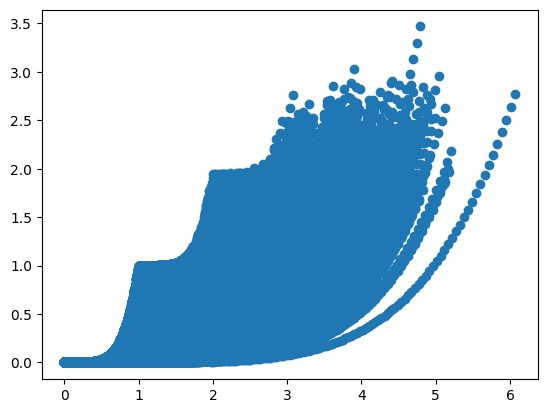

In [9]:
plt.scatter(train_data[:1000000]["bed1"], train_data[:1000000]["bed2"]);

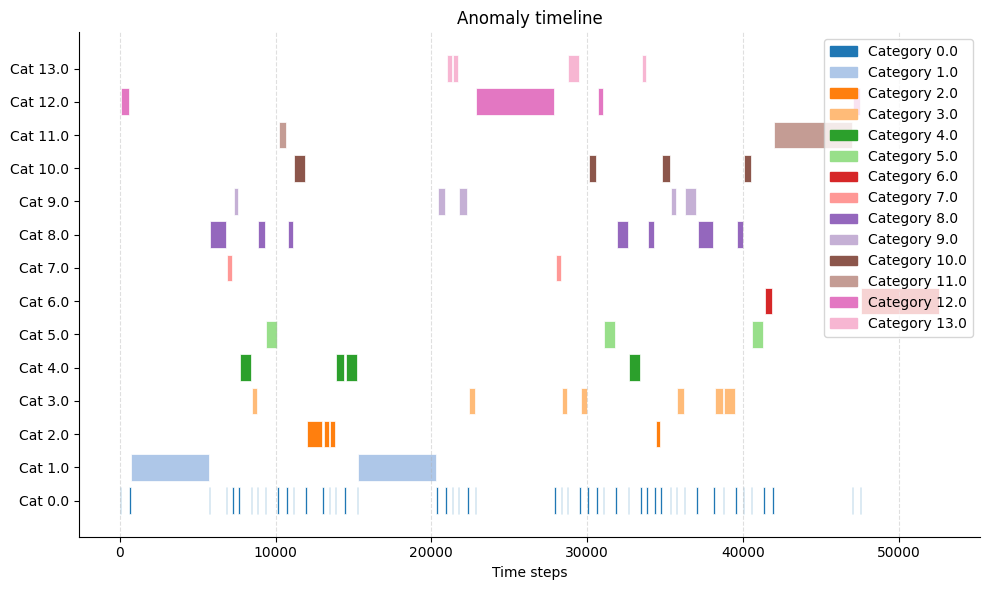

In [12]:
eda = raw_data[1000000:3500000].drop(columns = ["timestamp"])
eda["group"] = (eda["category"] != eda["category"].shift()).cumsum()
eda = eda[["category", "group"]]

anomalies = eda.groupby('group').agg(
    start=('category', lambda x: x.index[0] - eda.index[0]),
    width=('category', lambda x: x.count() if x.iloc[0] != 0 else 100),
    anomaly_type=('category', 'first')
).reset_index(drop=True)
anomalies['start'] = anomalies['width'].shift(fill_value=0).cumsum()
anomalies_slice = anomalies[0:100]
cats = sorted(anomalies_slice["anomaly_type"].unique())
y_pos = {c: int(i) for i, c in enumerate(cats)}

colors = plt.cm.tab20.colors
cat_color = {c: colors[i % 14] for i, c in enumerate(cats)}

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(anomalies_slice)):
    a = anomalies_slice.iloc[i]
    ax.broken_barh(
        [(a["start"], a["width"])],   
        (y_pos[a["anomaly_type"]] - 0.4, 0.8), 
        facecolors=cat_color[a["anomaly_type"]],
        edgecolors="white",
        linewidth=0.5,
    )

ax.set_yticks(range(len(cats)))
ax.set_yticklabels([f"Cat {c}" for c in cats])
ax.set_xlabel("Time steps")
ax.set_title("Anomaly timeline")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=cat_color[c], label=f"Category {c}") for c in cats]
ax.legend(handles=handles, loc="upper right")

plt.tight_layout()
plt.show()

In [13]:
root = "c:\\Architectural-Biases-in-Time-Series-Anomaly-Detection"
def create_dict(name):
    path = os.path.join(root, "saved_model_scores", name)
    with np.load(path) as data:
       results = {name: metric for name, metric in data.items()}
    return results
lstm_f_results = create_dict("lstm_f_results.npz")
lstm_ae_results = create_dict("lstm_ae_results.npz")
transformer_f_results = create_dict("transformer_f_results.npz")

In [14]:
f_scores = lstm_f_results["v_scores"]
f_labels = lstm_f_results["v_labels"]
f_cats = lstm_f_results["v_categories"]

transformer_scores = transformer_f_results["v_scores"]
transformer_labels = transformer_f_results["v_labels"]
transformer_cats = transformer_f_results["v_categories"]

ae_scores = lstm_ae_results["v_scores"]
ae_labels = lstm_ae_results["v_labels"]
ae_cats = lstm_ae_results["v_categories"]

window_grid = np.linspace(1, 800, 10)

In [15]:
def generate_df(scores, labels, cats, window_grid):
    series = []

    for window in window_grid:
        window = int(window)
        current_score = np.convolve(scores, np.ones(window) / window, mode='same')
        threshold = np.percentile(current_score, 100 - 4.4)
        cat_dict = {}
        normal_mask = cats == 0
        FPR = np.sum(current_score[normal_mask] > threshold) / np.sum(normal_mask)
        cat_dict["FPR (0.0)"] = round(float(FPR), 2)

        for cat in np.unique(cats):
            if cat == 0.0:
                continue
            cat_mask = cats == cat
            recall = np.sum(current_score[cat_mask] > threshold) / np.sum(cat_mask)
            cat_dict[f"recall ({cat})"] = round(float(recall), 2)

        TP = np.sum((current_score > threshold) & (labels == 1))
        FP = np.sum((current_score > threshold) & (labels == 0))
        recall = TP / np.sum(labels == 1)
        precision = TP / (TP + FP)
        F1 = 2 * (precision * recall) / (precision + recall)
        cat_dict["F1"] = np.round(F1, 3)

        series.append(pd.Series(cat_dict, name=f"t={threshold:.2f}|w={window}"))

    return pd.concat(series, axis=1)
generate_df(f_scores, f_labels, f_cats, window_grid)


,t=33.55|w=1,t=29.59|w=89,t=28.42|w=178,t=27.48|w=267,t=27.52|w=356,t=27.99|w=444,t=29.47|w=533,t=30.96|w=622,t=33.91|w=711,t=39.97|w=800
FPR (0.0),0.030,0.020,0.020,0.020,0.02,0.020,0.020,0.020,0.020,0.020
recall (1.0),0.750,0.860,0.880,0.900,0.92,0.940,0.960,0.970,0.980,0.990
recall (2.0),0.190,0.280,0.310,0.330,0.33,0.340,0.350,0.320,0.340,0.350
recall (3.0),0.660,0.840,0.940,0.940,0.97,0.990,1.000,0.930,0.910,0.910
recall (4.0),0.420,0.500,0.550,0.590,0.62,0.650,0.670,0.700,0.690,0.700
recall (5.0),0.040,0.020,0.010,0.010,0.02,0.030,0.040,0.040,0.050,0.060
recall (6.0),0.140,0.240,0.260,0.300,0.33,0.370,0.380,0.360,0.290,0.270
recall (7.0),0.390,0.460,0.480,0.510,0.53,0.550,0.550,0.540,0.510,0.480
recall (8.0),0.680,0.790,0.830,0.840,0.84,0.850,0.860,0.870,0.870,0.850
recall (9.0),0.400,0.710,0.840,0.920,0.93,0.930,0.910,0.930,0.870,0.790
